# Assignment 1

Deadline: 19.03.2026, 12:00 CET

- Marcel Blagotinšek, 25-744-202, marcel.blagotinsek@uzh.ch
- Lyuben Baltadzhiev, 25-739-046, lyubenmiroslavov.baltadzhiev@uzh.ch
- Michal Andrzejewski, 25-737-503, michalmaria.andrzejewski@uzh.ch
- Lorenzo Pagliani, 25-741-430, lorenzo.pagliani@uzh.ch
- Lorenzo Barbero, 25-743-709, lorenzo.barbero@uzh.ch

In [1]:
# Import standard libraries
import os
import sys
import timeit
from typing import Optional

# Import third-party libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import qpsolvers

# Import local modules
cwd = os.getcwd()

if os.path.basename(cwd) == "assignments":
    project_root = os.path.dirname(cwd)
else:
    project_root = cwd

src_path = os.path.join(project_root, "src")

if project_root not in sys.path:
    sys.path.append(project_root)
if src_path not in sys.path:
    sys.path.append(src_path)

from estimation.covariance import Covariance, is_pos_def, make_pos_def
from estimation.expected_return import ExpectedReturn
from optimization.constraints import Constraints
from optimization.optimization import Optimization, Objective
from optimization.optimization_data import OptimizationData
from optimization.quadratic_program import QuadraticProgram, USABLE_SOLVERS
from helper_functions import simulate_correlated_gbm

## 1. Solver Horse Race

### 1.a)
(3 points)

Generate a synthetic dataset of dimension TxN, T=1000, N=50, and compute a vector of expected returns, q, and a covariance matrix, P, using classes ExpectedReturn and Covariance respectively.

In [2]:
# Set the dimensions
T = 1000       # Number of time steps
N = 50         # Number of assets
rnd_seed = 42  # Random seed for reproducibility

# Set random seed for reproducibility
np.random.seed(rnd_seed)

# Generate a random mean vector
mu = np.random.uniform(0.02, 0.15, size=N)

# Generate a positive definite covariance matrix
eigenvalues = np.random.uniform(0.05, 0.30, size=N)
Lambda = np.diag(eigenvalues)

H = np.random.randn(N, N)
Q, _ = np.linalg.qr(H)

sigma = Q @ Lambda @ Q.T

# Rescale to a correlation matrix with random volatilities
std_devs = np.sqrt(np.diag(sigma))
corr_matrix = sigma / np.outer(std_devs, std_devs)

vols = np.random.uniform(0.10, 0.30, size=N)
sigma = np.diag(vols) @ corr_matrix @ np.diag(vols)

# Make sure the covariance matrix is positive definite.
print("Is sigma positive definite?", is_pos_def(sigma))

# Generate correlated geometric Brownian motion paths and compute discrete returns
prices = simulate_correlated_gbm(mu=mu, sigma=sigma, T=T, random_seed=None)
returns = prices.pct_change().dropna()

# Compute the vector of expected returns
q = ExpectedReturn().estimate(returns, inplace=False)

# Compute the covariance matrix
P = Covariance().estimate(returns, inplace=False)

# Display the results
print("Vector of expected returns (q):")
print(q)

print("\nCovariance matrix (P):")
print(P)

Is sigma positive definite? True
Vector of expected returns (q):
Asset_1     0.000112
Asset_2     0.000227
Asset_3     0.000453
Asset_4    -0.000029
Asset_5    -0.000142
Asset_6    -0.000068
Asset_7     0.000048
Asset_8     0.000486
Asset_9     0.000067
Asset_10   -0.000092
Asset_11   -0.000166
Asset_12    0.000118
Asset_13    0.000318
Asset_14   -0.000016
Asset_15    0.000278
Asset_16   -0.000292
Asset_17    0.000084
Asset_18   -0.000083
Asset_19   -0.000122
Asset_20    0.000159
Asset_21    0.000224
Asset_22   -0.000109
Asset_23    0.000128
Asset_24    0.000133
Asset_25   -0.000034
Asset_26    0.000261
Asset_27   -0.000305
Asset_28   -0.000021
Asset_29   -0.000008
Asset_30    0.000058
Asset_31    0.000174
Asset_32    0.000057
Asset_33    0.000236
Asset_34    0.000499
Asset_35   -0.000078
Asset_36    0.000068
Asset_37    0.000246
Asset_38    0.000097
Asset_39    0.000026
Asset_40    0.000119
Asset_41   -0.000071
Asset_42    0.000153
Asset_43    0.000012
Asset_44   -0.000015
Asset_45   

### 1.b)
(3 points)

Instantiate a constraints object by injecting column names of the return series created in 1.a) as ids and add:
- a budget constaint (i.e., asset weights have to sum to one)
- lower bounds of 0.0 for all assets
- upper bounds of 0.2 for all assets
- group contraints such that the sum of the weights of the first 15 assets is <= 0.3, the sum of assets 16 to 45 is <= 0.4 and the sum of assets 41 to 50 is <= 0.5

In [3]:
# Instantiate the Constraints class
constraints = Constraints(ids=returns.columns.tolist())

# Add budget constraint
constraints.add_budget(rhs=1, sense='=')

# Add box constraints (i.e., lower and upper bounds)
constraints.add_box(lower=0, upper=0.2)

# Add linear constraints
G = pd.DataFrame(np.zeros((3, N)), columns=constraints.ids)
G.iloc[0, 0:15] = 1
G.iloc[1, 15:45] = 1
G.iloc[2, 40:50] = 1

h = pd.Series([0.3, 0.4, 0.5])
constraints.add_linear(G=G, sense='<=', rhs=h)

# Display some columns of the G matrix to verify that the constraints have been set up correctly
constraints.linear['G'][['Asset_1', 'Asset_15', 'Asset_16', 'Asset_40', 'Asset_41', 'Asset_50']]

,Asset_1,Asset_15,Asset_16,Asset_40,Asset_41,Asset_50
0,1.0,1.0,0.0,0.0,0.0,0.0
1,0.0,0.0,1.0,1.0,1.0,0.0
2,0.0,0.0,0.0,0.0,1.0,1.0


### 1.c) 
(4 points)

Solve a Mean-Variance optimization problem (using coefficients P and q in the objective function) which satisfies the above defined constraints.
Repeat the task for all open-source solvers in qpsolvers that you could install and compare the results in terms of:

- runtime
- accuracy: value of the primal problem.
- reliability: are all constraints fulfilled? Extract primal residuals, dual residuals and duality gap.

Generate a DataFrame with the solvers as column names and the following row index: 'solution_found': bool, 'objective': float, 'primal_residual': float, 'dual_residual': float, 'duality_gap': float, 'runtime': float.

Put NA's for solvers where the optimization failed for some reason.

In [4]:
import qpsolvers

print(qpsolvers.available_solvers)

['cvxopt', 'daqp', 'osqp', 'qpalm', 'qtqp', 'quadprog']


In [5]:
# Extract constraints in solver form
GhAb = constraints.to_GhAb()

# Result template for failed solvers
result_on_fail = {
    'solution_found': False,
    'objective': np.nan,
    'primal_residual': np.nan,
    'dual_residual': np.nan,
    'duality_gap': np.nan,
    'runtime': np.nan,
}

# Loop over solvers, instantiate the quadratic program, solve it and store the results in a dictionary.

# Mean-variance scaling
risk_aversion = 1

# Solvers that were installed / tested
solvers_to_test = ['cvxopt', 'osqp', 'quadprog', 'daqp', 'qtqp']
results = {}

for solver in solvers_to_test:
    try:
        qp = QuadraticProgram(
            P=P.to_numpy() * risk_aversion,
            q=-q.to_numpy(),
            G=GhAb['G'],
            h=GhAb['h'],
            A=GhAb['A'],
            b=GhAb['b'],
            lb=constraints.box['lower'].to_numpy(),
            ub=constraints.box['upper'].to_numpy(),
            solver=solver,
        )

        start = timeit.default_timer()
        qp.solve()
        runtime = timeit.default_timer() - start

        solution = qp.results.get('solution')
        found = getattr(solution, 'found', False)

        gap = np.nan
        if found:
            gap = solution.duality_gap()
            if isinstance(gap, (list, tuple, np.ndarray)):
                gap = gap[0]

        results[solver] = {
            'solution_found': found,
            'objective': qp.objective_value() if found else np.nan,
            'primal_residual': solution.primal_residual() if found else np.nan,
            'dual_residual': solution.dual_residual() if found else np.nan,
            'duality_gap': gap if found else np.nan,
            'runtime': runtime,
        }

    except Exception:
        results[solver] = result_on_fail.copy()

# qpalm crashed the kernel in testing, so record it as failed
results['qpalm'] = result_on_fail.copy()

Print and visualize the results

Solver comparison:


,cvxopt,osqp,quadprog,daqp,qtqp,qpalm
solution_found,True,True,True,True,False,False
objective,-0.000306,-0.000304,-0.000306,-0.000306,NaN,NaN
primal_residual,0.0,0.000351,0.0,0.0,NaN,NaN
dual_residual,0.0,0.000004,0.0,0.0,NaN,NaN
duality_gap,0.0,0.000002,0.0,0.0,NaN,NaN
runtime,0.073328,0.005056,0.000983,0.000937,NaN,NaN


Successful solvers: ['cvxopt', 'osqp', 'quadprog', 'daqp']


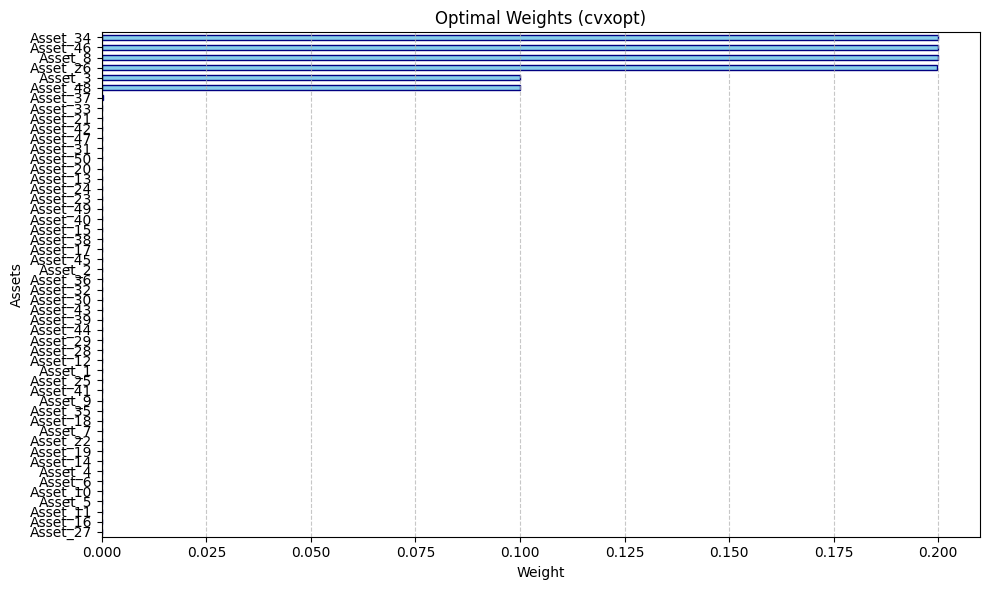

Holdings for cvxopt:
Asset_34    1.999996e-01
Asset_46    1.999983e-01
Asset_8     1.999909e-01
Asset_26    1.997196e-01
Asset_3     1.000048e-01
Asset_48    9.999930e-02
Asset_37    2.609731e-04
Asset_33    5.391406e-06
Asset_21    2.254056e-06
Asset_42    1.678275e-06
Asset_47    1.342547e-06
Asset_31    1.181412e-06
Asset_50    9.765220e-07
Asset_20    8.889240e-07
Asset_13    8.231185e-07
Asset_24    6.856991e-07
Asset_23    6.719267e-07
Asset_49    6.707546e-07
Asset_40    6.162136e-07
Asset_15    5.905478e-07
Asset_38    5.151871e-07
Asset_17    4.673146e-07
Asset_45    4.536515e-07
Asset_2     4.329482e-07
Asset_36    4.231201e-07
Asset_32    3.987213e-07
Asset_30    3.972641e-07
Asset_43    3.777789e-07
Asset_39    3.500541e-07
Asset_44    3.332614e-07
Asset_29    3.074366e-07
Asset_28    2.957254e-07
Asset_12    2.920740e-07
Asset_1     2.880506e-07
Asset_25    2.842135e-07
Asset_41    2.731030e-07
Asset_9     2.611081e-07
Asset_35    2.527409e-07
Asset_18    2.471916e-07
Asse

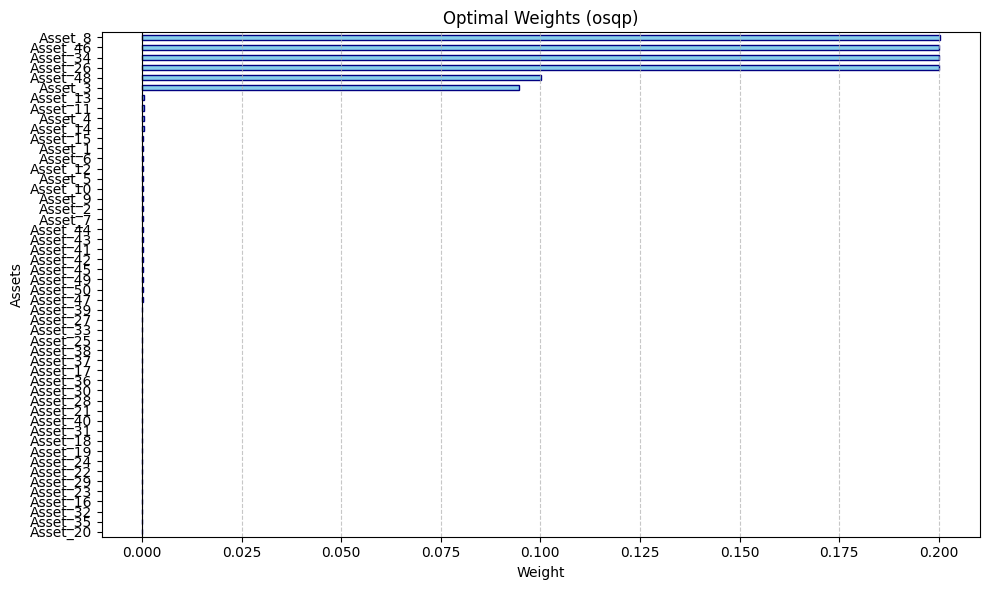

Holdings for osqp:
Asset_8     0.200351
Asset_46    0.200122
Asset_34    0.199987
Asset_26    0.199963
Asset_48    0.100063
Asset_3     0.094544
Asset_13    0.000399
Asset_11    0.000380
Asset_4     0.000376
Asset_14    0.000372
Asset_15    0.000357
Asset_1     0.000357
Asset_6     0.000357
Asset_12    0.000355
Asset_5     0.000351
Asset_10    0.000347
Asset_9     0.000340
Asset_2     0.000333
Asset_7     0.000293
Asset_44    0.000211
Asset_43    0.000201
Asset_41    0.000194
Asset_42    0.000193
Asset_45    0.000179
Asset_49    0.000145
Asset_50    0.000117
Asset_47    0.000116
Asset_39   -0.000014
Asset_27   -0.000023
Asset_33   -0.000032
Asset_25   -0.000032
Asset_38   -0.000033
Asset_37   -0.000036
Asset_17   -0.000037
Asset_36   -0.000039
Asset_30   -0.000039
Asset_28   -0.000039
Asset_21   -0.000042
Asset_40   -0.000042
Asset_31   -0.000042
Asset_18   -0.000043
Asset_19   -0.000044
Asset_24   -0.000045
Asset_22   -0.000045
Asset_29   -0.000048
Asset_23   -0.000053
Asset_16   -0.0

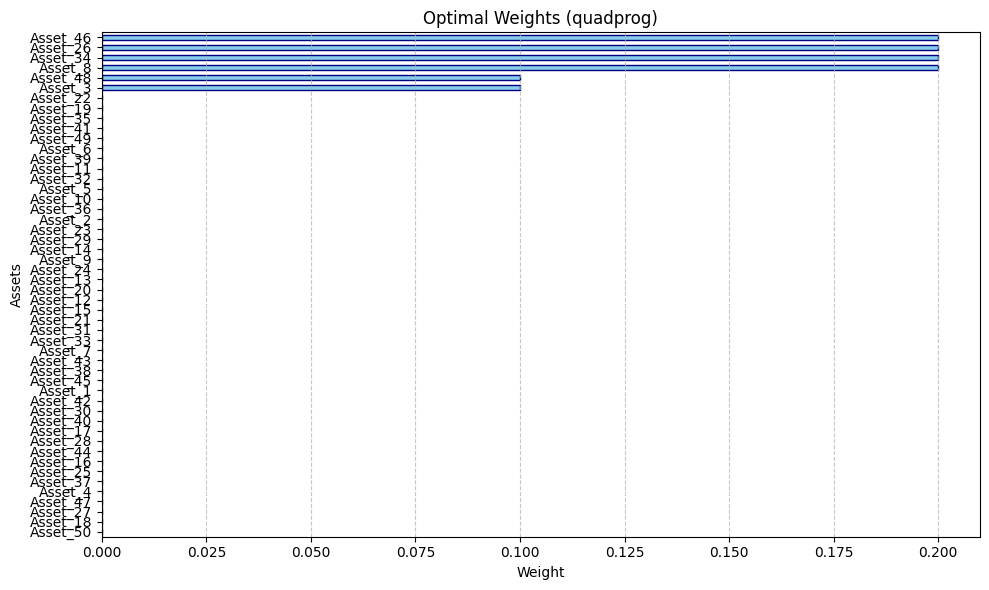

Holdings for quadprog:
Asset_46    2.000000e-01
Asset_26    2.000000e-01
Asset_34    2.000000e-01
Asset_8     2.000000e-01
Asset_48    1.000000e-01
Asset_3     1.000000e-01
Asset_22    3.784350e-15
Asset_19    2.600447e-15
Asset_35    1.511601e-15
Asset_41    1.391822e-15
Asset_49    8.202501e-16
Asset_6     5.788070e-16
Asset_39    3.885956e-16
Asset_11    3.467643e-16
Asset_32    2.848517e-16
Asset_5     2.460638e-16
Asset_10    2.410192e-16
Asset_36    1.963397e-16
Asset_2     1.141188e-16
Asset_23    1.101942e-16
Asset_29    5.170128e-17
Asset_14    3.650483e-17
Asset_9     3.153352e-17
Asset_24    2.772309e-18
Asset_13    0.000000e+00
Asset_20   -8.369196e-19
Asset_12   -3.215106e-18
Asset_15   -9.595758e-18
Asset_21   -1.000770e-17
Asset_31   -1.976998e-17
Asset_33   -2.006493e-17
Asset_7    -2.012696e-17
Asset_43   -5.320906e-17
Asset_38   -6.280580e-17
Asset_45   -6.330206e-17
Asset_1    -6.907920e-17
Asset_42   -1.011577e-16
Asset_30   -1.602802e-16
Asset_40   -2.283445e-16
As

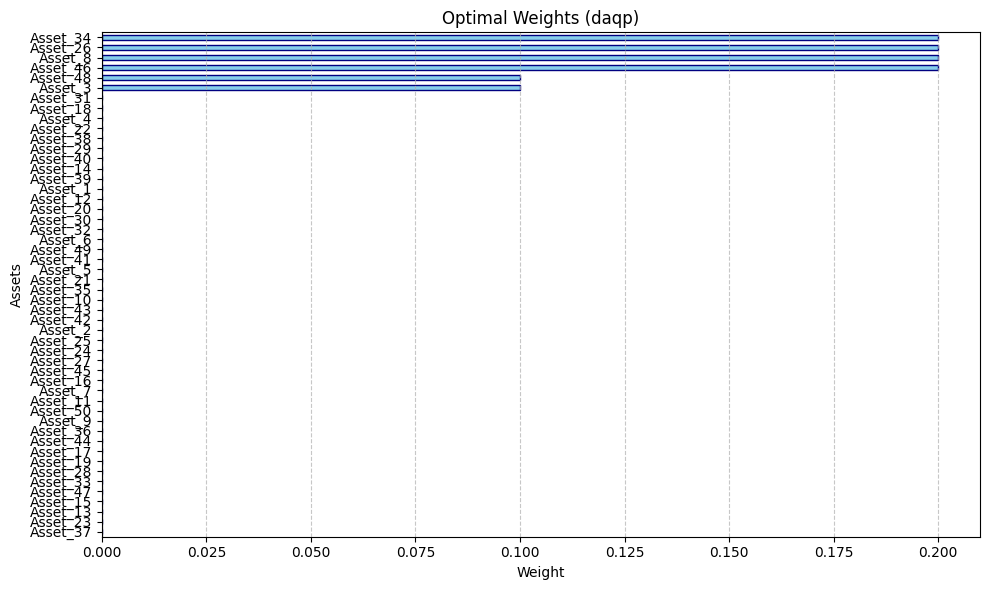

Holdings for daqp:
Asset_34    2.000000e-01
Asset_26    2.000000e-01
Asset_8     2.000000e-01
Asset_46    2.000000e-01
Asset_48    1.000000e-01
Asset_3     1.000000e-01
Asset_31    3.387455e-14
Asset_18    1.678619e-14
Asset_4     1.514305e-14
Asset_22    1.155537e-14
Asset_38    6.362204e-15
Asset_29    5.525947e-15
Asset_40    4.306696e-15
Asset_14    3.933626e-15
Asset_39    3.932395e-15
Asset_1     3.132000e-15
Asset_12    2.758540e-15
Asset_20    2.474734e-15
Asset_30    2.449394e-15
Asset_32    2.198673e-15
Asset_6     1.436521e-15
Asset_49    1.316115e-15
Asset_41    4.658790e-16
Asset_5    -3.205338e-16
Asset_21   -4.542720e-16
Asset_35   -5.067304e-16
Asset_10   -6.673519e-16
Asset_43   -1.203525e-15
Asset_42   -1.868678e-15
Asset_2    -2.121842e-15
Asset_25   -2.276490e-15
Asset_24   -2.338499e-15
Asset_27   -3.952901e-15
Asset_45   -3.953502e-15
Asset_16   -4.118639e-15
Asset_7    -4.622116e-15
Asset_11   -5.055615e-15
Asset_50   -5.220456e-15
Asset_9    -5.722501e-15
Asset_

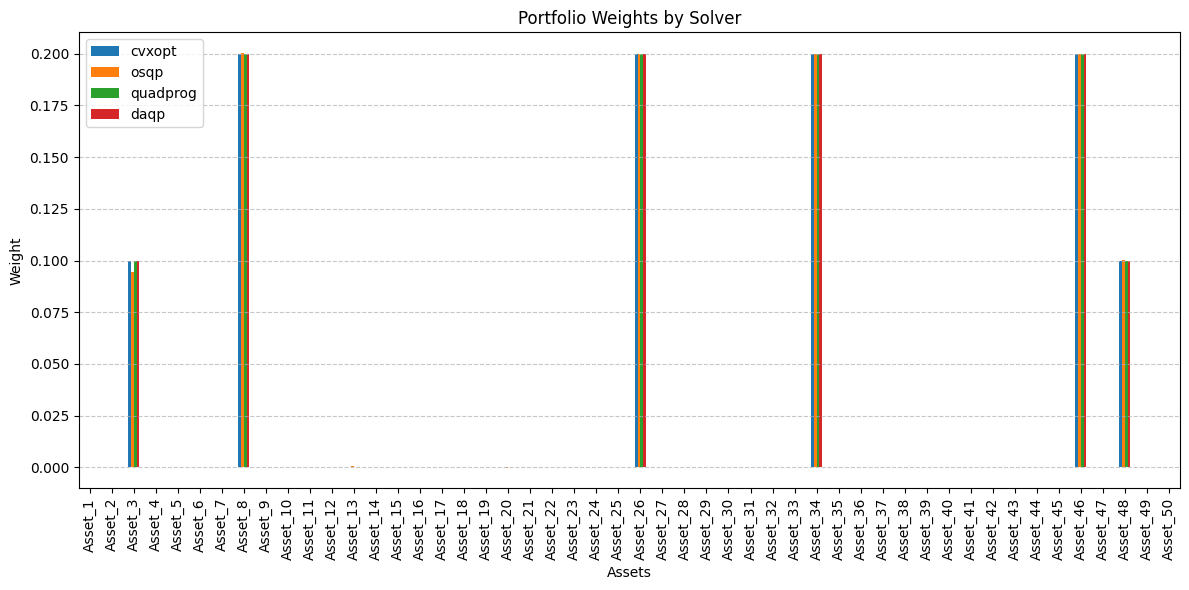

In [6]:
# Comparison table: solvers as columns, metrics as rows
results_df = pd.DataFrame(results)

print("Solver comparison:")
display(results_df)

# Successful solvers
solvers_to_plot = ['cvxopt', 'osqp', 'quadprog', 'daqp', 'qtqp']
successful_solvers = [
    s for s in solvers_to_plot
    if s in results_df.columns and bool(results_df.loc['solution_found', s])
]

print("Successful solvers:", successful_solvers)

weights_by_solver = {}

for solver_to_plot in successful_solvers:
    qp_plot = QuadraticProgram(
        P=P.to_numpy() * risk_aversion,
        q=-q.to_numpy(),
        G=GhAb['G'],
        h=GhAb['h'],
        A=GhAb['A'],
        b=GhAb['b'],
        lb=constraints.box['lower'].to_numpy(),
        ub=constraints.box['upper'].to_numpy(),
        solver=solver_to_plot,
    )

    qp_plot.solve()
    solution_plot = qp_plot.results.get('solution')

    weights = pd.Series(solution_plot.x, index=returns.columns, name=solver_to_plot)
    weights_by_solver[solver_to_plot] = weights

    plt.figure(figsize=(10, 6))
    weights.sort_values().plot(
        kind='barh',
        color='skyblue',
        edgecolor='navy'
    )
    plt.title(f'Optimal Weights ({solver_to_plot})')
    plt.xlabel('Weight')
    plt.ylabel('Assets')
    plt.axvline(x=0, color='black', linewidth=0.8)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    print(f"Holdings for {solver_to_plot}:")
    print(weights.sort_values(ascending=False))
    print()

# Combined weight comparison
if weights_by_solver:
    weights_compare_df = pd.DataFrame(weights_by_solver)

    plt.figure(figsize=(12, 6))
    weights_compare_df.plot(kind='bar', ax=plt.gca())
    plt.title('Portfolio Weights by Solver')
    plt.xlabel('Assets')
    plt.ylabel('Weight')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

## 2. Analytical Solution to Minimum-Variance Problem

(5 points)

- Create a `MinVariance` class that follows the structure of the `MeanVariance` class.
- Implement the `solve` method in `MinVariance` such that if `solver_name = 'analytical'`, the analytical solution is computed and stored within the object (if such a solution exists). If not, call the `solve` method from the parent class.
- Create a `Constraints` object by injecting the same ids as in part 1.b) and add a budget constraint.
- Instantiate a `MinVariance` object by setting `solver_name = 'analytical'` and passing instances of `Constraints` and `Covariance` as arguments.
- Create an `OptimizationData` object that contains an element `return_series`, which consists of the synthetic data generated in part 1.a).
- Solve the optimization problem using the created `MinVariance` object and compare the results to those obtained in part 1.c).


In [7]:
# Define class MinVariance
class MinVariance(Optimization):

    def __init__(self,
                 constraints: Constraints,
                 covariance: Optional[Covariance] = None,
                 **kwargs):
        super().__init__(
            constraints=constraints,
            **kwargs
        )
        self.covariance = Covariance() if covariance is None else covariance

    def set_objective(self, optimization_data: OptimizationData) -> None:
        X = optimization_data['return_series']
        covmat = self.covariance.estimate(X=X, inplace=False)
        n_assets = covmat.shape[0]

        self.objective = Objective(
            q=np.zeros(n_assets),
            P=covmat * 2,
        )
        return None

    def solve(self) -> None:
        if self.params.get('solver_name') == 'analytical':
            GhAb = self.constraints.to_GhAb()
            A = GhAb['A']
            b = GhAb['b']
            G = GhAb['G']
            h = GhAb['h']

            if G is not None or h is not None:
                raise ValueError("Analytical solution only applies to equality constraints Ax = b.")

            lower = self.constraints.box.get('lower')
            upper = self.constraints.box.get('upper')
            if lower is not None or upper is not None:
                lower_np = None if lower is None else np.asarray(lower, dtype=float)
                upper_np = None if upper is None else np.asarray(upper, dtype=float)

                has_finite_lower = lower_np is not None and np.isfinite(lower_np).any()
                has_finite_upper = upper_np is not None and np.isfinite(upper_np).any()

                if has_finite_lower or has_finite_upper:
                    raise ValueError("Analytical solution only applies to equality constraints Ax = b.")

            if A is None or b is None:
                raise ValueError("Analytical minimum-variance solution requires equality constraints Ax = b.")

            P = self.objective.coefficients['P']
            Sigma = np.asarray(P, dtype=float) / 2.0
            A = np.asarray(A, dtype=float)
            b = np.asarray(b, dtype=float).reshape(-1, 1)

            if not is_pos_def(Sigma):
                raise ValueError("Analytical solution requires Sigma to be positive definite.")

            Sigma_inv = np.linalg.inv(Sigma)
            middle = A @ Sigma_inv @ A.T

            if np.linalg.matrix_rank(middle) < middle.shape[0]:
                raise ValueError("Analytical solution requires A Sigma^{-1} A^T to be invertible.")

            middle_inv = np.linalg.inv(middle)
            x_star = Sigma_inv @ A.T @ middle_inv @ b
            x_star = x_star.flatten()

            self.results = {
                'weights': x_star,
                'status': True,
                'solver': 'analytical'
            }
            return None

        else:
            return super().solve()
        
# Create a constraints object with just a budget constraint
constraints_mv = Constraints(ids=returns.columns.tolist())
constraints_mv.add_budget(rhs=1, sense='=')

# Instantiate the MinVariance class
minvar = MinVariance(
    constraints=constraints_mv,
    covariance=Covariance(check_positive_definite=True),
    solver_name='analytical'
)

# Prepare the optimization data and prepare the optimization problem
optimization_data = OptimizationData(return_series=returns)

# Solve the optimization problem and print the weights
minvar.set_objective(optimization_data=optimization_data)
minvar.solve()

weights_minvar = pd.Series(minvar.results['weights'], index=returns.columns, name='Analytical')
print("Analytical minimum-variance weights:")
print(weights_minvar)
print("\nSum of weights:", weights_minvar.sum())


Analytical minimum-variance weights:
Asset_1     0.004001
Asset_2     0.012058
Asset_3     0.038712
Asset_4     0.075012
Asset_5     0.023790
Asset_6    -0.004303
Asset_7     0.006397
Asset_8     0.008923
Asset_9    -0.002294
Asset_10    0.014340
Asset_11    0.008019
Asset_12    0.008548
Asset_13    0.017138
Asset_14    0.009928
Asset_15   -0.001887
Asset_16    0.016335
Asset_17    0.036146
Asset_18    0.034152
Asset_19    0.029072
Asset_20    0.008207
Asset_21    0.016694
Asset_22    0.022691
Asset_23    0.073971
Asset_24   -0.001732
Asset_25    0.017848
Asset_26   -0.009655
Asset_27   -0.001180
Asset_28    0.097097
Asset_29    0.004808
Asset_30    0.062156
Asset_31    0.023553
Asset_32    0.011919
Asset_33    0.039555
Asset_34    0.010168
Asset_35    0.025415
Asset_36    0.040932
Asset_37    0.013188
Asset_38    0.020456
Asset_39    0.002303
Asset_40    0.008778
Asset_41   -0.001705
Asset_42   -0.001205
Asset_43   -0.002734
Asset_44    0.012455
Asset_45    0.013849
Asset_46    0.0528

### Appendix for 2.)



Numerical minimum-variance weights:
Asset_1     0.004001
Asset_2     0.012058
Asset_3     0.038712
Asset_4     0.075012
Asset_5     0.023790
Asset_6    -0.004303
Asset_7     0.006397
Asset_8     0.008923
Asset_9    -0.002294
Asset_10    0.014340
Asset_11    0.008019
Asset_12    0.008548
Asset_13    0.017138
Asset_14    0.009928
Asset_15   -0.001887
Asset_16    0.016335
Asset_17    0.036146
Asset_18    0.034152
Asset_19    0.029072
Asset_20    0.008207
Asset_21    0.016694
Asset_22    0.022691
Asset_23    0.073971
Asset_24   -0.001732
Asset_25    0.017848
Asset_26   -0.009655
Asset_27   -0.001180
Asset_28    0.097097
Asset_29    0.004808
Asset_30    0.062156
Asset_31    0.023553
Asset_32    0.011919
Asset_33    0.039555
Asset_34    0.010168
Asset_35    0.025415
Asset_36    0.040932
Asset_37    0.013188
Asset_38    0.020456
Asset_39    0.002303
Asset_40    0.008778
Asset_41   -0.001705
Asset_42   -0.001205
Asset_43   -0.002734
Asset_44    0.012455
Asset_45    0.013849
Asset_46    0.0528

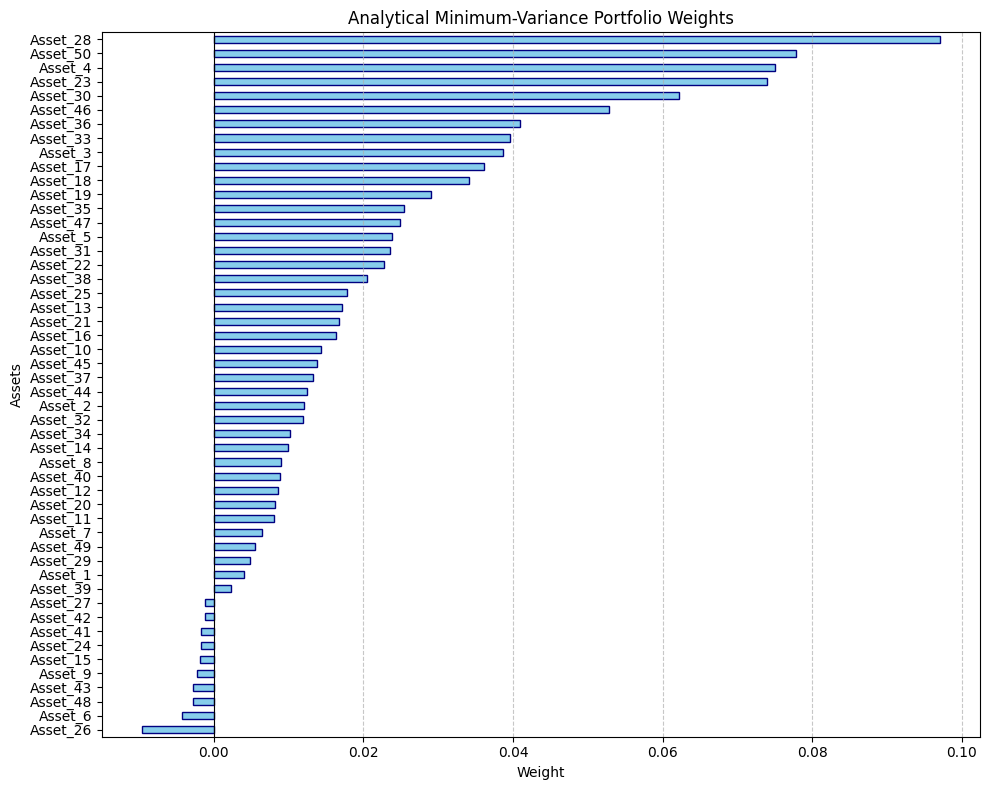

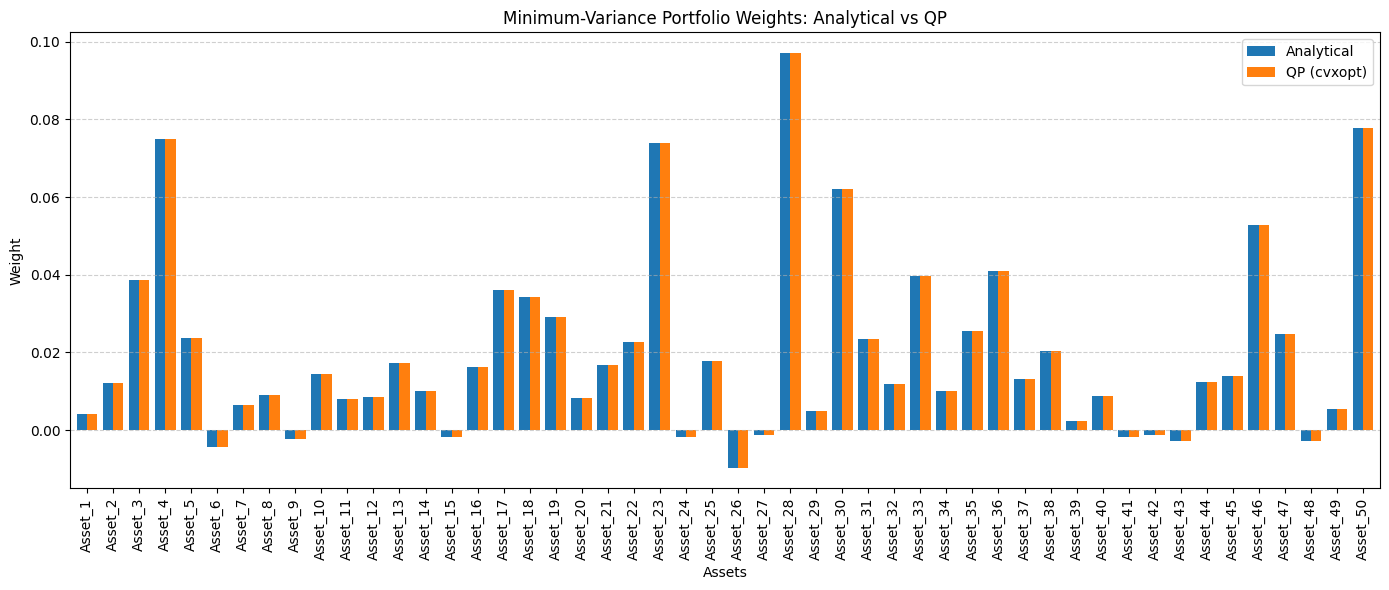

Objective value (Analytical): 3.558873877666016e-07
Objective value (QP): 3.558873877666016e-07


In [8]:
# Appendix: we wanted to compare the analytical solution to the numerical solver we used before

# Solve numerically for comparison
minvar_qp = MinVariance(
    constraints=constraints_mv,
    covariance=Covariance(check_positive_definite=True),
    solver_name='cvxopt'
)

minvar_qp.set_objective(optimization_data=optimization_data)
minvar_qp.solve()

weights_minvar_qp = pd.Series(minvar_qp.results['weights'], index=returns.columns, name='QP (cvxopt)')
print("\nNumerical minimum-variance weights:")
print(weights_minvar_qp)
print("\nSum of weights:", weights_minvar_qp.sum())

# Compare both solutions
comparison_df = pd.DataFrame({
    'Analytical': weights_minvar,
    'QP (cvxopt)': weights_minvar_qp
})

# Visualization of analytical vs numerical minimum-variance solution

comparison_df = pd.DataFrame({
    'Analytical': weights_minvar,
    'QP (cvxopt)': weights_minvar_qp
})

# Plot the nalytical weights
plt.figure(figsize=(10, 8))
weights_minvar.sort_values().plot(
    kind='barh',
    color='skyblue',
    edgecolor='navy'
)
plt.title('Analytical Minimum-Variance Portfolio Weights')
plt.xlabel('Weight')
plt.ylabel('Assets')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Plot the analytical vs numerical comparison
plt.figure(figsize=(14, 6))
comparison_df.plot(kind='bar', ax=plt.gca(), width=0.8)
plt.title('Minimum-Variance Portfolio Weights: Analytical vs QP')
plt.xlabel('Assets')
plt.ylabel('Weight')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Compute objective values
obj_analytical = 0.5 * weights_minvar.to_numpy() @ minvar.objective.coefficients['P'] @ weights_minvar.to_numpy()
obj_qp = 0.5 * weights_minvar_qp.to_numpy() @ minvar_qp.objective.coefficients['P'] @ weights_minvar_qp.to_numpy()

print("Objective value (Analytical):", obj_analytical)
print("Objective value (QP):", obj_qp)